# Q2 - Portfolio Effects: Property Restrictions focused

**Author:** Madison Woo

**Dataset:** `CHAPA_Chapter-40B_Application-Data_2021-2025_merged_v0.1.csv` (https://drive.google.com/file/d/18MMJX8-of-zEqgs3gvd2wXN92QG3O43Y/view?usp=drive_link)

**Instruction**: Download the CSV file above and move it to the `ds-chapa-affordable-housing/fa25-team-a/data` folder, then run the cells below

## Count of Property Restriction

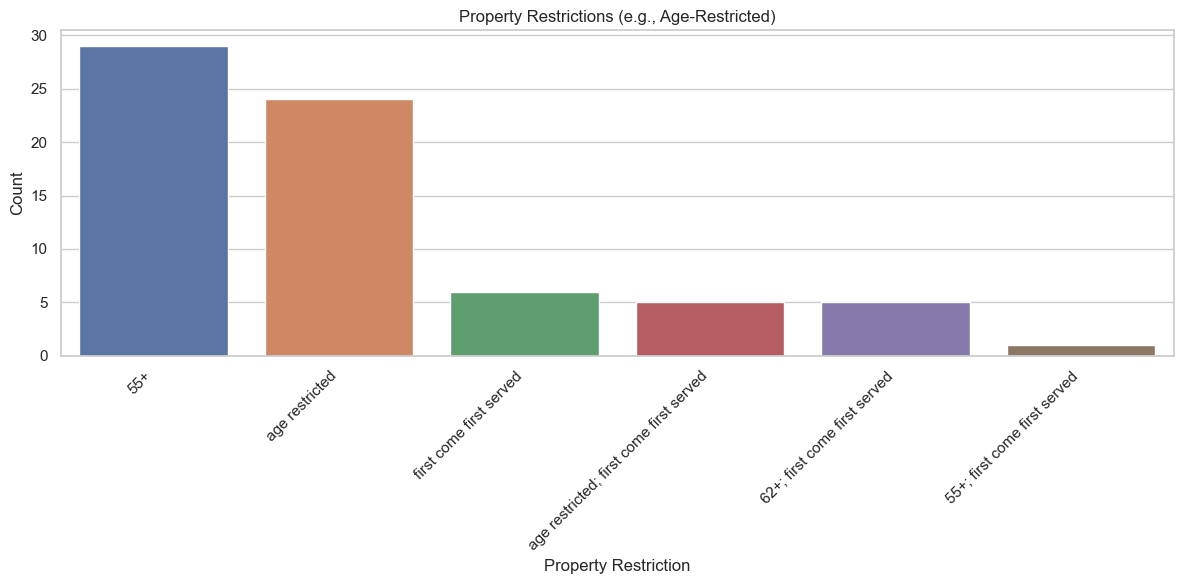

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# loading data 
df = pd.read_csv('../data/CHAPA_Chapter-40B_Application-Data_2021-2025_merged_v0.1.csv')

sns.set(style = "whitegrid")

# breakdown of property restriction
plt.figure(figsize = (12,6))  # wider figure
sns.countplot(data = df, x = 'property_restriction')
plt.title('Property Restrictions (e.g., Age-Restricted)')
plt.xlabel('Property Restriction')
plt.ylabel('Count')
plt.xticks(rotation = 45, ha = 'right')  # Rotate and align labels right for readability
plt.tight_layout()
plt.show()

# remove non-numeric chars and convert to float in hh_income
df['hh_income_clean'] = (
    df['hh_income']
    .astype(str)
    .str.replace(r'[^0-9.]', '', regex=True)
)
df['hh_income_clean'] = pd.to_numeric(df['hh_income_clean'], errors = 'coerce')

Most properties are age-restricted, which naturally limits demographic patterns. 

## Applicant Race Proportions by Property Restriction

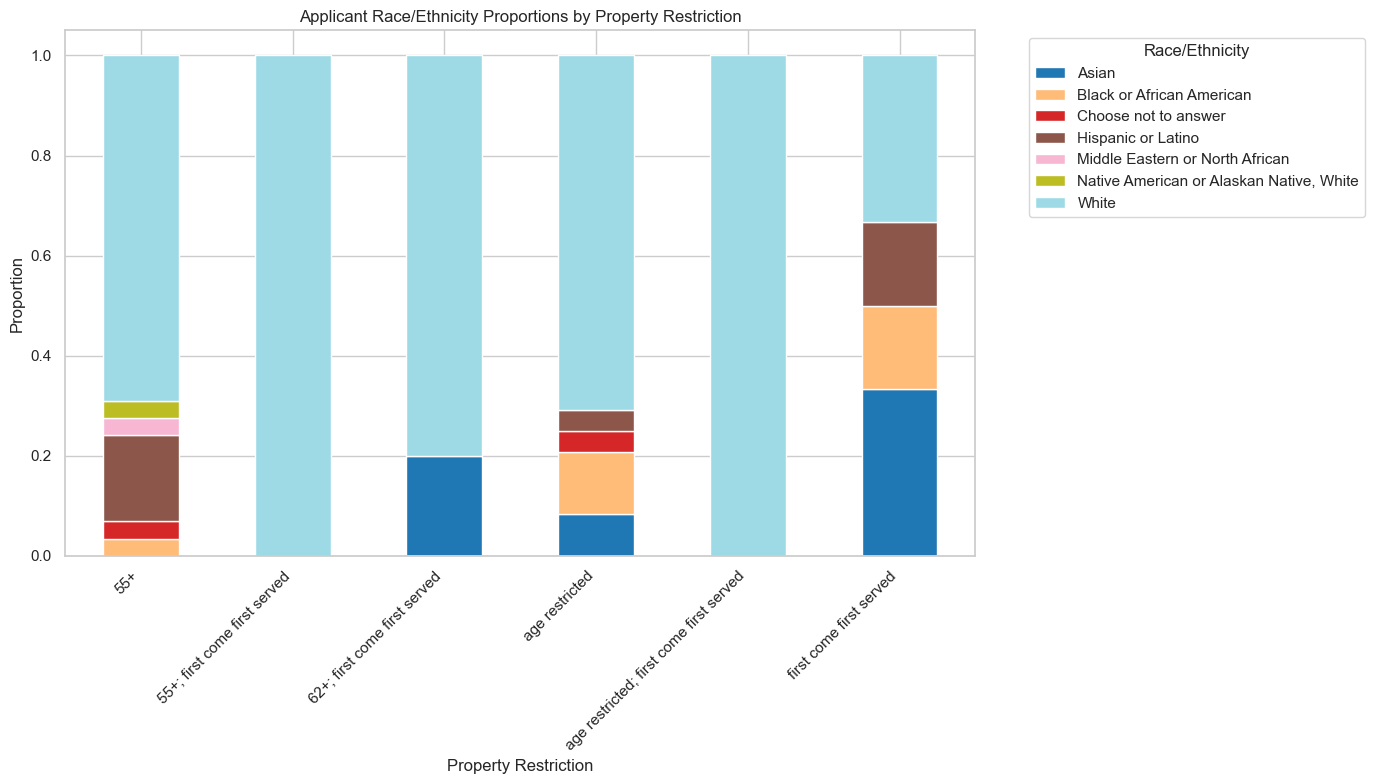

In [16]:
# applicant race/ethnicity proportions by property restriction
race_props = pd.crosstab(df['property_restriction'], df['chapa_races'], normalize = 'index')
ax = race_props.plot(kind = 'bar', stacked = True, figsize = (14,8), colormap = 'tab20')
plt.title('Applicant Race/Ethnicity Proportions by Property Restriction')
plt.xlabel('Property Restriction')
plt.ylabel('Proportion')
plt.xticks(rotation = 45, ha = 'right')  # Same here
plt.legend(title = 'Race/Ethnicity', bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.tight_layout()
plt.show()

The chart illustrates that while White applicants make up the majority in the age-restricted property categories such as "55+" and "age restricted," there is still a meaningful representation of diverse racial and ethnic groups within these segments, including Asian, Black or African American, and Hispanic or Latino applicants. This indicates that age restrictions in CHAPA’s property portfolio influence applicant demographics primarily by limiting applicant age but do not exclusively restrict racial or ethnic diversity. In contrast, properties categorized as "first come first served" without age restrictions tend to attract a broader and more diverse applicant pool, suggesting that demographic variation in these segments is more strongly driven by applicant choice and outreach efforts rather than portfolio limitations. Overall, the data shows that CHAPA’s property restrictions shape the applicant pool to some extent, particularly by age, but significant racial and ethnic diversity persists, especially in less restricted properties where applicant preferences have greater influence.

## Local vs. Non-local Applicants

Percentage of applicants residing in same town as property applied to: 9.72%


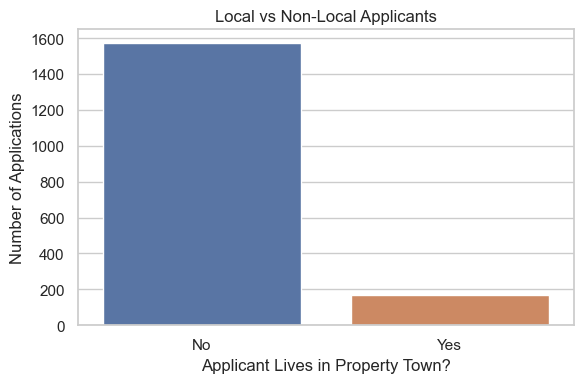

In [12]:
# local vs. non-local applicants 

df['current_residence_town_city'] = df['current_residence_town_city'].str.lower()
df['property_town_city'] = df['property_town_city'].str.lower()
df['local_applicant'] = df['current_residence_town_city'] == df['property_town_city']

local_rate = df['local_applicant'].mean()
print(f'Percentage of applicants residing in same town as property applied to: {local_rate:.2%}')

plt.figure(figsize = (6,4))
sns.countplot(data = df, x = 'local_applicant')
plt.title('Local vs Non-Local Applicants')
plt.xlabel('Applicant Lives in Property Town?')
plt.ylabel('Number of Applications')
plt.xticks(ticks = [0,1], labels = ['No', 'Yes'])
plt.tight_layout()
plt.show()

This graph shows us how many applicants live in the same town where they apply. It appears that a majority of applicants apply to properties that are not in their hometown. This indicicates that applicant choice plays a bigger role shaping demographics. 